In [1]:
import numpy as np
import matplotlib.pyplot as plt
# %matplotlib widget
import seaborn as sns
sns.set_style("whitegrid")

from cone import CircularCone3D
from evaluation import check

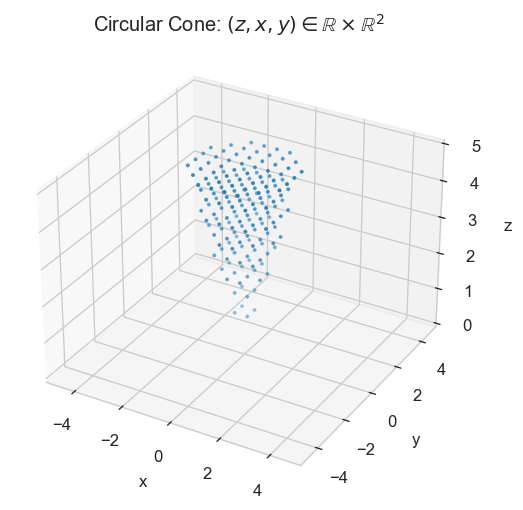

In [2]:
bdd = 5
num = 20
theta = np.pi/8

cone = CircularCone3D(boundary=bdd, number=num, theta=theta, verbose=True)
x,y,z = cone.x, cone.y, cone.z # x_1=z in R and x_2=[x,y] in R^2
n = x.shape[0] # number of points in cone

In [3]:
breaker = False
point_idx = []
for i in range(n):
    for j in range(i, n):
        vec_1 = np.array([z[i], x[i], y[i]])
        vec_2 = np.array([z[j], x[j], y[j]])

        if check(vec_1, vec_2, theta).bool:
            pass
        else:
            print("found case not in SOC")
            print(i,j)
            point_idx.append([i,j])
    #         breaker = True
    #         break
    # if breaker:
    #     break

found case not in SOC
0 0
found case not in SOC
0 1
found case not in SOC
0 2
found case not in SOC
0 3
found case not in SOC
0 4
found case not in SOC
0 5
found case not in SOC
0 6
found case not in SOC
0 7
found case not in SOC
0 8
found case not in SOC
0 9
found case not in SOC
0 10
found case not in SOC
0 11
found case not in SOC
0 12
found case not in SOC
0 13
found case not in SOC
0 14
found case not in SOC
0 15
found case not in SOC
0 16
found case not in SOC
0 17
found case not in SOC
0 18
found case not in SOC
0 19
found case not in SOC
0 20
found case not in SOC
0 21
found case not in SOC
0 22
found case not in SOC
0 23
found case not in SOC
0 24
found case not in SOC
0 25
found case not in SOC
0 26
found case not in SOC
0 27
found case not in SOC
0 28
found case not in SOC
0 29
found case not in SOC
0 30
found case not in SOC
0 31
found case not in SOC
0 32
found case not in SOC
0 33
found case not in SOC
0 34
found case not in SOC
0 35
found case not in SOC
0 36
found case 

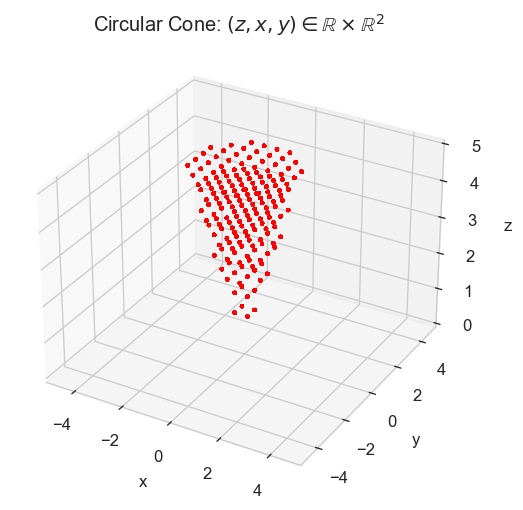

In [4]:
points = []
for idx in point_idx:
    points.append([x[idx[0]], y[idx[0]], z[idx[0]]])
    points.append([x[idx[1]], y[idx[1]], z[idx[1]]])

if len(points) != 0:
    cone.plotCone(np.array(points))
else:
    print("certified")

In [5]:
# Ex

i = 12
j = 13

p1 = np.array([z[i], x[i], y[i]])
p2 = np.array([z[j], x[j], y[j]])

print("point 1:", p1)
print("point 2:", p2)

print("-"*60)
if p1[0] >= np.linalg.norm(p1[1:])*(1/np.tan(theta)):
    print("point 1 is in circular cone with theta {} deg".format(np.round(theta*(180/np.pi),2)))
if p2[0] >= np.linalg.norm(p2[1:])*(1/np.tan(theta)):
    print("point 2 is in circular cone with theta {} deg".format(np.round(theta*(180/np.pi),2)))

def inv(vec):
    norm = np.linalg.norm(vec[1:])
    lambda_1_inv = 1/(vec[0] - norm*(1/np.tan(theta)))
    lambda_2_inv = 1/(vec[0] + norm*np.tan(theta))
    # print("lambda 1", lambda_1_inv)
    # print((1/np.tan(theta)))
    # print("lambda 2", lambda_2_inv)
    # print(np.tan(theta))
    x_1 = lambda_1_inv*np.sin(theta)**2 + lambda_2_inv*np.cos(theta)**2
    if norm == 0:
        w = np.zeros(len(vec[1:]))
        w[0] = 1
        x_2 = (lambda_2_inv-lambda_1_inv)*(np.sin(theta)*np.cos(theta))*w
    else:
        x_2 = (lambda_2_inv-lambda_1_inv)*(np.sin(theta)*np.cos(theta))*(vec[1:]/norm)
    return np.insert(x_2, 0, x_1, axis=0)

print("-"*60)
A = (p1 + p2)/2

t1 = inv(p1)
t2 = inv(p2)
H = inv((t1+t2)/2)
# H = inv((inv(p1)+ inv(p2))/2)
vector2check = A - H

if vector2check[0] >= np.linalg.norm(vector2check[1:])*(1/np.tan(theta)):
    print("A - H is in SOC")
else:
    print("A - H is not in SOC")
    print("x1=", vector2check[0])
    print("||x2||=", np.linalg.norm(vector2check[1:]))
    print("x1 < ||x2||")

point 1: [ 3.33333333  0.26315789 -1.31578947]
point 2: [ 3.88888889  0.26315789 -1.31578947]
------------------------------------------------------------
point 1 is in circular cone with theta 22.5 deg
point 2 is in circular cone with theta 22.5 deg
------------------------------------------------------------
A - H is not in SOC
x1= 3.2124473473615494
||x2||= 1.6131590350438871
x1 < ||x2||


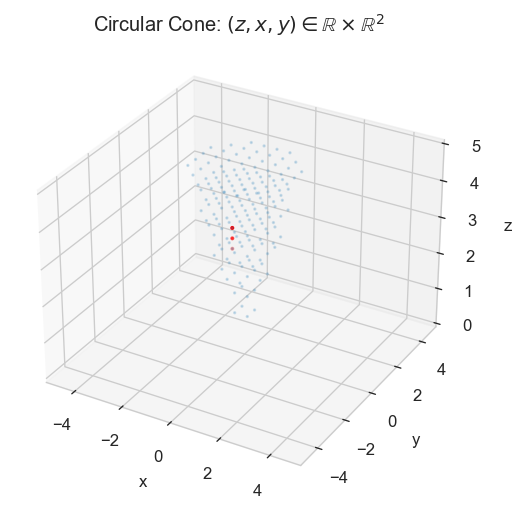

In [6]:
cone.plotCone(np.array([[p1[1], p1[2], p1[0]],
                        [p2[1], p2[2], p2[0]],
                        [A[1], A[2], A[0]]
                        ]))

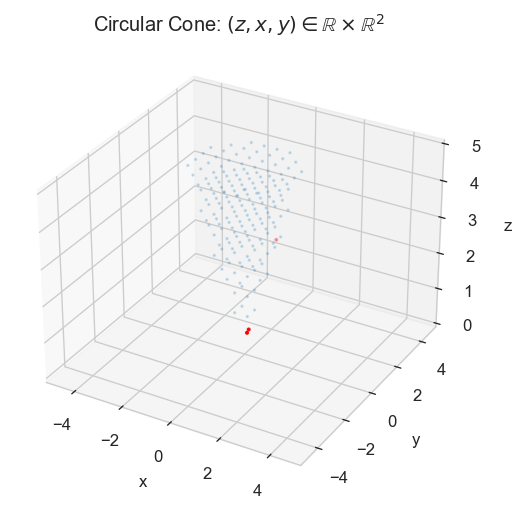

In [7]:
cone.plotCone(np.array([[inv(p1)[1], inv(p1)[2], inv(p1)[0]],
                        [inv(p2)[1], inv(p2)[2], inv(p2)[0]],
                        [H[1], H[2], H[0]]
                        ]))